In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
import pandas as pd
import glob
from scipy.signal import find_peaks
import math
from scipy.optimize import curve_fit
from sympy import symbols, solve
import glob
from scipy.signal import find_peaks
import seaborn as sns

C:\Users\bachd\AppData\Local\Temp\ipykernel_20396\3566441013.py:71: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "-k" (-> color='k'). The keyword argument will take precedence.
  plt.plot(w/(2*math.pi), mag, '-k', color='#292929', label='Model')    # Bode magnitude plot
C:\Users\bachd\AppData\Local\Temp\ipykernel_20396\3566441013.py:73: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "-k" (-> color='k'). The keyword argument will take precedence.
  plt.plot(w/(2*math.pi), mag, '-k', color='#292929')    # Bode magnitude plot


Text(0.5, 0, 'Frequency (Hz)')

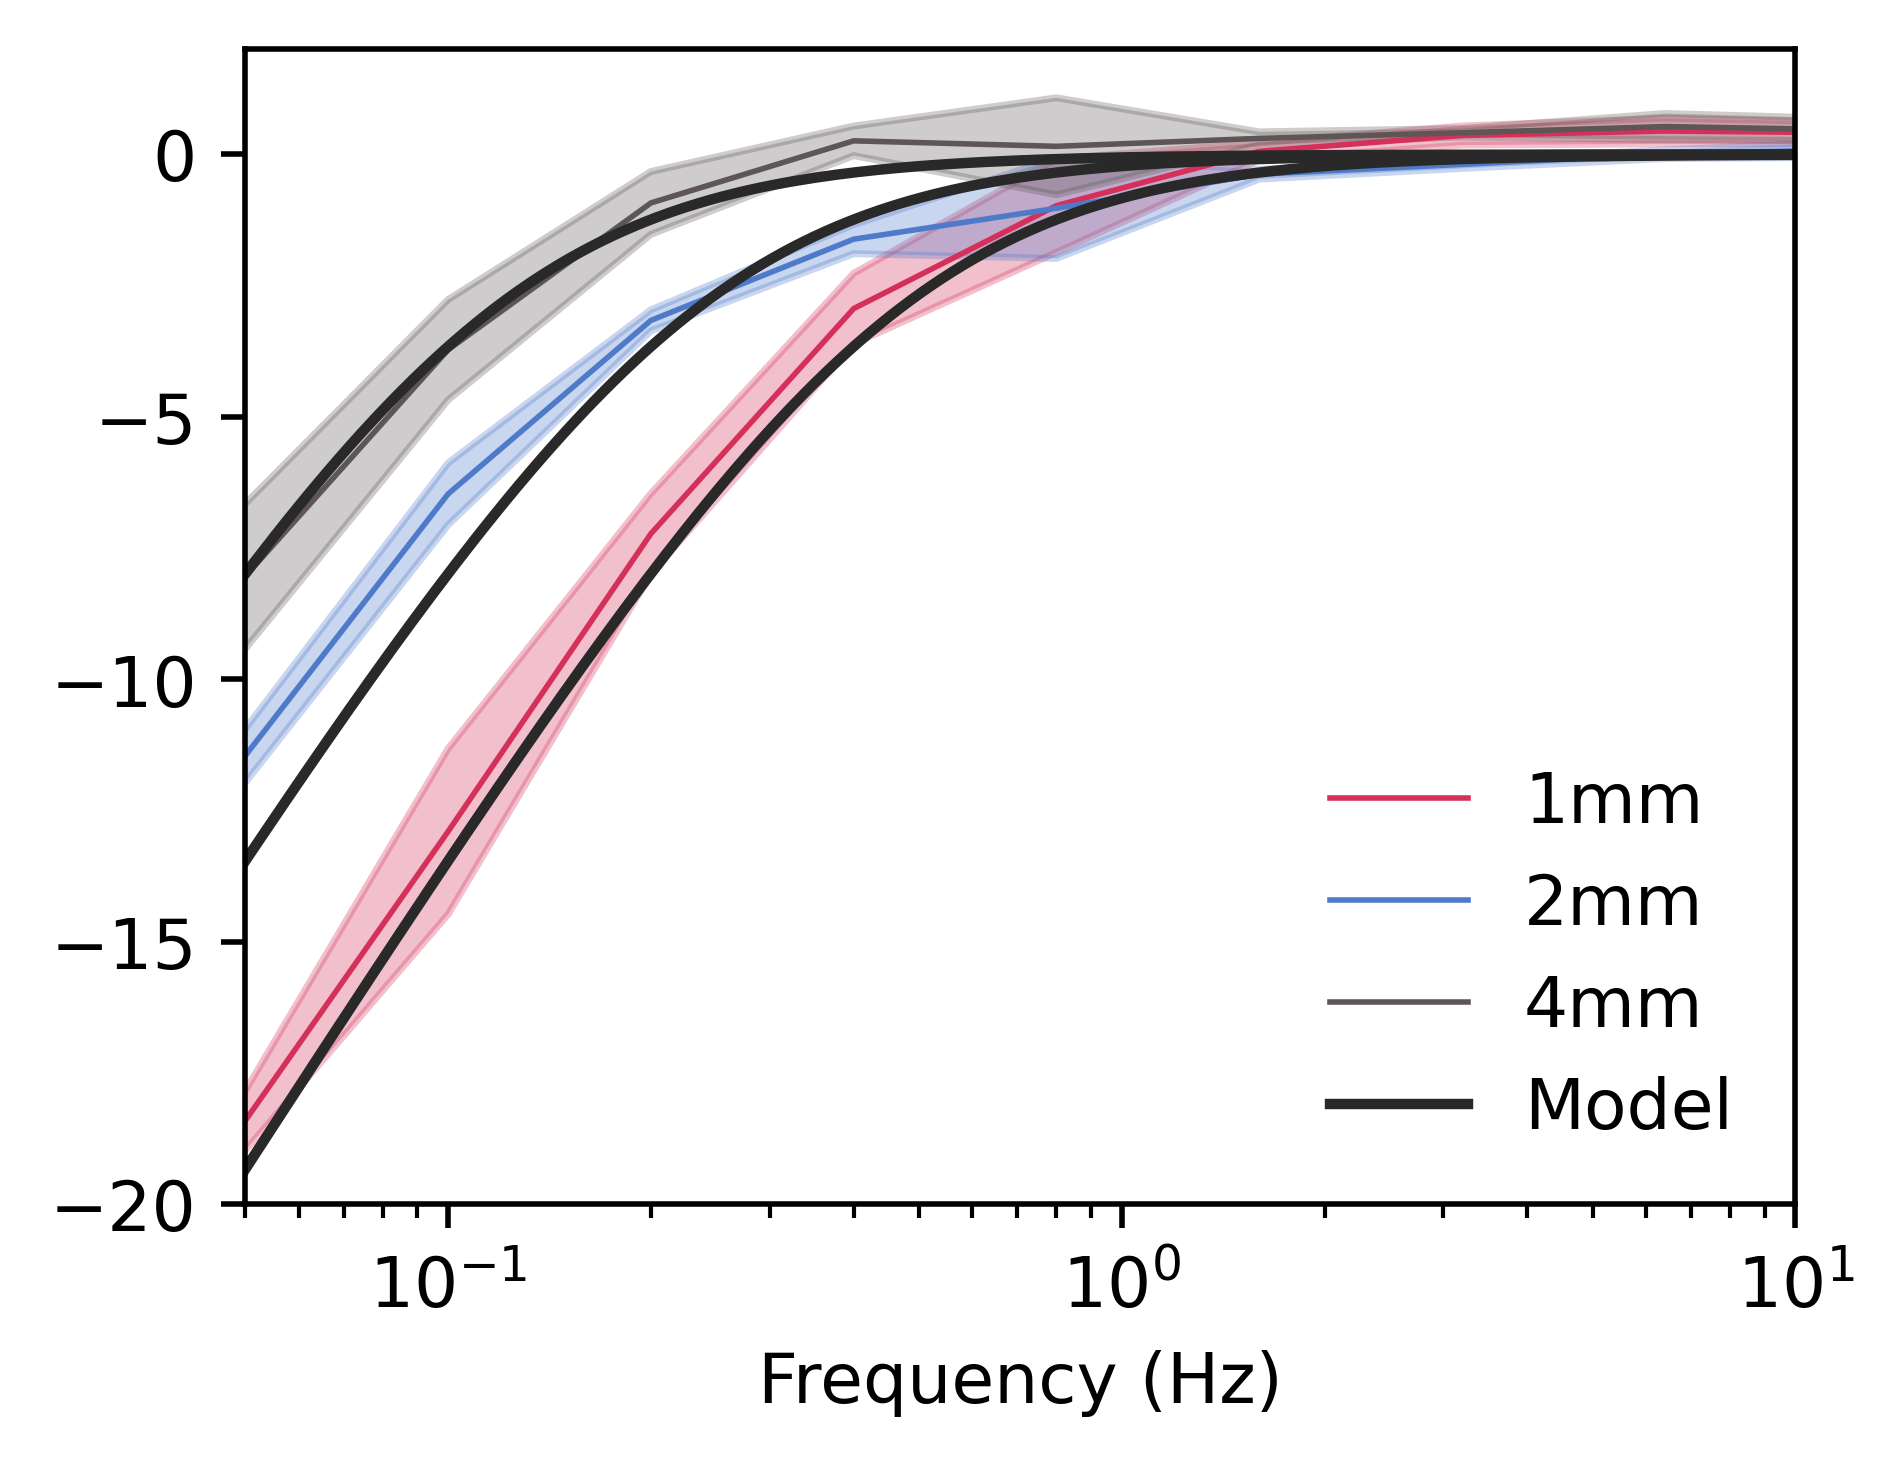

In [13]:
mm_1 = ['Fig3g_1mm(1).csv',
         'Fig3g_1mm(2).csv',
         'Fig3g_2mm(1).csv',
         'Fig3g_2mm(2).csv',
         'Fig3g_4mm(1).csv',
         'Fig3g_4mm(2).csv']
plt.figure(figsize=(4, 3), dpi=500)
plt.ylim(-20, 2)
plt.xscale('log')
colors = ['#D43059', '#5E5656', '#4F7ACA', '#7A9CC1', '#5E5656', '#888080']

freq = [0.025, 0.05, 0.1, 0.2, 0.4, 0.8, 1.6, 3.2, 6.4, 12.8, 25]
volume = ['1mm', '2mm', '4mm']
# for file in glob.glob('250109_testCTL_*mm_*_00*.csv'):
for u in range(3):
    DT = []
    tt = 0
    for i in range(11):
        dt = []
        for j in range(2):
            file = mm_1[u*2 + j]
            a = pd.read_csv(file, skiprows=8, skipfooter=3, engine="python")
            fsr = 100
            raw = a.iloc[:, 2].astype(np.float64).to_numpy()
            resistance = raw
            resistance /= np.mean(resistance)
            resistance -= 1
            resistance = resistance[30*fsr:]         
            segment = resistance[tt+10*fsr:(tt+int((int(40*freq[i])+2)*(1/freq[i]))*fsr)-10*fsr]
            segment -= np.mean(segment)
           
            if freq[i] < 10:
                sos = signal.butter(2, freq[i]*2, 'low', fs=fsr, output='sos')
                segment = signal.sosfilt(sos, segment)
            # try:
            #     sos = signal.butter(2, freq[i]*2, 'lp', fs=fsr, output='sos')
            #     segment = signal.sosfilt(sos, segment)
            # except:
            #     pass
            pks_high, _ = find_peaks(segment, prominence=0.0002, width=1)
            pks_low, _ = find_peaks(-segment, prominence=0.0002, width=1)
            # plt.figure()
            # plt.plot(segment)
            # plt.scatter(pks_high, segment[pks_high], color='red')
            # plt.scatter(pks_low, segment[pks_low], color='blue')
            for l in range(min(len(pks_high), len(pks_low))): dt.append(segment[pks_high[l]]-segment[pks_low[l]])
        tt += int((int(40*freq[i])+2)*(1/freq[i]))*fsr+10*fsr
        # print(dt)
        DT.append(dt)
    # print(DT)
    M = []
    N = []
    base = []
    for dt in DT[-4:]:
        base.append(np.mean(dt))
    base = np.mean(base)
    for dt in DT:
        dt = 20 * np.log10(dt / base)
        M.append(np.mean(dt))
        N.append(dt.std(ddof=0))
    plt.plot(freq, M, lw=0.8, label=volume[u],  color=colors[u*2])
    plt.fill_between(freq, np.array(M)-np.array(N), np.array(M)+np.array(N), alpha=0.3, color=colors[u*2])
    plt.legend(frameon=False)

for u in [1, 2, 4]:
    sys = signal.TransferFunction([1, 0], [-1, 0.46*(2*math.pi)/u])
    w, mag, phase = signal.bode(sys, w=np.logspace(-2*(2*math.pi), 0.5*(2*math.pi), 1000))
    # plt.figure()
    plt.xlim(0.05, 10)
    if u == 1:
        plt.plot(w/(2*math.pi), mag, '-k', color='#292929', label='Model')    # Bode magnitude plot
    else:
        plt.plot(w/(2*math.pi), mag, '-k', color='#292929')    # Bode magnitude plot
plt.legend(frameon=False)
plt.xlabel('Frequency (Hz)')
# plt.ylabel('Normalized ∆R (dB)')